# 06 — Sequential Bands Curriculum (C^E paper variant)

Builds the paper's **C^E** curriculum from an existing influence matrix — no GPU or surrogate retraining needed.

**What it does:**
- Aggregates influence scores across all checkpoints: `φ_T = mean(Φ, axis=1)`
- Sorts documents easy → hard (higher influence = easier, per paper)
- Splits into `N_SEGMENTS` equal, non-overlapping difficulty bands
- Epoch k trains exclusively on band k (equal-length epochs, zero overlap)

**Inputs (from SOURCE_DATASET_REPO):**
- `influence_matrix.npy` — shape (D, T)
- `doc_ids.json` — list of D doc IDs matching Phi rows
- `curriculum/epoch_00.jsonl` … — any existing epoch file to reconstruct `id → text`

**Outputs (pushed to TARGET_DATASET_REPO):**
- `epoch_00.jsonl` … `epoch_{N-1}.jsonl` — one file per band, `{"id", "text"}` per line

In [ ]:
# ── Cell 1: Config ──
SOURCE_DATASET_REPO = "flakoash/babylm-curriculum-run07"   # "flakoash/babylm-curriculum-run05"  — has Phi + epoch JSOMLs
TARGET_DATASET_REPO = "flakoash/babylm-curriculum-sliding-window-4bands"   # "flakoash/babylm-sequential-bands-run05"  — destination
HF_TOKEN            = ""   # or: import os; HF_TOKEN = os.environ["HF_TOKEN"]

N_SEGMENTS = 4   # number of epoch files produced

# "sequential"    — non-overlapping bands (paper C^E). Each epoch sees 1/N of the corpus.
# "sliding_window" — fixed-size window that shifts from easy end to hard end each epoch.
#                    Epochs overlap heavily; alleviates source-imbalance in strict bands.
STRATEGY    = "sliding_window"
WINDOW_FRAC = 0.5   # sliding_window only: fraction of corpus per epoch (0 < x < 1)

SEED       = 0    # controls within-epoch shuffle

OUTPUT_DIR = "./outputs/sequential_bands"

print(f"Source      : {SOURCE_DATASET_REPO}")
print(f"Target      : {TARGET_DATASET_REPO}")
print(f"Strategy    : {STRATEGY}" + (f"  window={WINDOW_FRAC:.0%}" if STRATEGY == "sliding_window" else ""))
print(f"N epochs    : {N_SEGMENTS}")

Source      : flakoash/babylm-curriculum-run07
Target      : flakoash/babylm-curriculum-sliding-window-4bands
Strategy    : sliding_window  window=50%
N epochs    : 4


In [2]:
# ── Cell 2: Imports + output dir ──
import json, random
from pathlib import Path

import numpy as np

OUT = Path(OUTPUT_DIR)
OUT.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


In [3]:
# ── Cell 3: Pull Phi + doc_ids from source Hub repo ──
phi_path = OUT / "influence_matrix.npy"
ids_path = OUT / "doc_ids.json"

if phi_path.exists() and ids_path.exists():
    print("Found cached Phi + doc_ids — skipping download.")
else:
    assert SOURCE_DATASET_REPO, "Set SOURCE_DATASET_REPO in Cell 1."
    from huggingface_hub import hf_hub_download
    print(f"Downloading from {SOURCE_DATASET_REPO} ...")
    hf_hub_download(SOURCE_DATASET_REPO, "influence_matrix.npy",
                    local_dir=str(OUT), repo_type="dataset", token=HF_TOKEN)
    hf_hub_download(SOURCE_DATASET_REPO, "doc_ids.json",
                    local_dir=str(OUT), repo_type="dataset", token=HF_TOKEN)

Phi     = np.load(str(phi_path))          # shape (D, T)
doc_ids = json.loads(ids_path.read_text()) # list of D strings
D, T    = Phi.shape
print(f"Phi shape : {Phi.shape}  (D={D} docs, T={T} checkpoints)")
print(f"doc_ids   : {len(doc_ids)} entries")

Found cached Phi + doc_ids — skipping download.
Phi shape : (726009, 2)  (D=726009 docs, T=2 checkpoints)
doc_ids   : 726009 entries


In [4]:
# ── Cell 4: Reconstruct id → text mapping from source epoch files ──
# The existing epoch JSOMLs have {"id": ..., "text": ...} per line.
# We only need to download one of them to cover the full document set
# (every epoch file is a permutation of all D docs).

text_cache = OUT / "_texts.jsonl"

if text_cache.exists():
    print("Found cached text mapping — skipping download.")
else:
    assert SOURCE_DATASET_REPO, "Set SOURCE_DATASET_REPO in Cell 1."
    from huggingface_hub import list_repo_files, hf_hub_download
    epoch_files_remote = sorted(
        f for f in list_repo_files(SOURCE_DATASET_REPO, repo_type="dataset", token=HF_TOKEN)
        if f.startswith("curriculum/epoch_") and f.endswith(".jsonl")
    )
    assert epoch_files_remote, "No curriculum/epoch_*.jsonl files found in source repo."
    # Download just the first epoch file — it contains all docs
    first_epoch = epoch_files_remote[0]
    print(f"Downloading {first_epoch} to extract texts ...")
    local_epoch = hf_hub_download(SOURCE_DATASET_REPO, first_epoch,
                                  repo_type="dataset", token=HF_TOKEN)
    import shutil
    shutil.copy(local_epoch, str(text_cache))

id_to_text = {}
with text_cache.open() as f:
    for line in f:
        rec = json.loads(line)
        id_to_text[rec["id"]] = rec["text"]

missing = [did for did in doc_ids if did not in id_to_text]
assert not missing, f"{len(missing)} doc_ids not found in epoch file — check source repo."

texts = [id_to_text[did] for did in doc_ids]   # ordered to match Phi rows
print(f"Reconstructed {len(texts):,} texts — aligned to Phi rows.")

Found cached text mapping — skipping download.
Reconstructed 726,009 texts — aligned to Phi rows.


In [5]:
# ── Cell 5: Build curriculum ──
# sequential     — epoch k = band k (1/N of sorted docs, no overlap)
# sliding_window — epoch k = fixed-size window shifted by step each epoch:
#                  epoch 0 anchored at easiest end, epoch N-1 at hardest end.

rng   = random.Random(SEED)
agg   = Phi.mean(axis=1)                   # aggregate influence: one score per doc
order = np.argsort(agg)[::-1].tolist()     # descending: highest influence = easiest

curr_dir = OUT / "curriculum"
curr_dir.mkdir(exist_ok=True)

if STRATEGY == "sequential":
    boundaries = [round(D * k / N_SEGMENTS) for k in range(N_SEGMENTS + 1)]
    bands = [order[boundaries[k] : boundaries[k + 1]] for k in range(N_SEGMENTS)]

elif STRATEGY == "sliding_window":
    assert 0 < WINDOW_FRAC < 1, "WINDOW_FRAC must be between 0 and 1."
    W    = round(D * WINDOW_FRAC)
    step = (D - W) / (N_SEGMENTS - 1) if N_SEGMENTS > 1 else 0
    bands = [order[round(k * step) : round(k * step) + W] for k in range(N_SEGMENTS)]

else:
    raise ValueError(f"Unknown STRATEGY: {STRATEGY!r}. Use 'sequential' or 'sliding_window'.")

for k, band in enumerate(bands):
    shuffled = band[:]
    rng.shuffle(shuffled)
    out_path = curr_dir / f"epoch_{k:02d}.jsonl"
    with out_path.open("w") as f:
        for idx in shuffled:
            f.write(json.dumps({"id": doc_ids[idx], "text": texts[idx]}) + "\n")

print(f"Curriculum written  strategy={STRATEGY}:")
for k, band in enumerate(bands):
    n        = len(band)
    score_hi = agg[band[0]]   # easiest in window (pre-shuffle order)
    score_lo = agg[band[-1]]  # hardest in window
    print(f"  epoch_{k:02d}.jsonl : {n:6,} docs   influence [{score_lo:.4f}, {score_hi:.4f}]")

Curriculum written  strategy=sliding_window:
  epoch_00.jsonl : 363,004 docs   influence [0.0534, 2.2915]
  epoch_01.jsonl : 363,004 docs   influence [-0.0213, 0.3881]
  epoch_02.jsonl : 363,004 docs   influence [-0.1278, 0.1607]
  epoch_03.jsonl : 363,004 docs   influence [-3.6805, 0.0534]


In [6]:
# ── Cell 5b: Write .txt mirrors ──
# One doc per line, blank line between docs — same format as notebook 04.

for k in range(N_SEGMENTS):
    jf = curr_dir / f"epoch_{k:02d}.jsonl"
    tf = jf.with_suffix(".txt")
    with jf.open() as src, tf.open("w") as dst:
        for line in src:
            dst.write(json.loads(line)["text"] + "\n\n")

print("TXT mirrors written:")
for k in range(N_SEGMENTS):
    tf = curr_dir / f"epoch_{k:02d}.txt"
    size_mb = tf.stat().st_size / 1e6
    print(f"  {tf.name}: {size_mb:.1f} MB")

TXT mirrors written:
  epoch_00.txt: 14.6 MB
  epoch_01.txt: 25.0 MB
  epoch_02.txt: 33.5 MB
  epoch_03.txt: 33.2 MB


In [9]:
# ── Cell 6: Sanity checks ──
from collections import Counter

all_ids = []
for k in range(N_SEGMENTS):
    with (curr_dir / f"epoch_{k:02d}.jsonl").open() as f:
        for line in f:
            all_ids.append(json.loads(line)["id"])

counts = Counter(all_ids)

if STRATEGY == "sequential":
    dupes = {k: v for k, v in counts.items() if v > 1}
    assert not dupes, f"{len(dupes)} docs appear in multiple bands."
    assert set(counts) == set(doc_ids), "Coverage mismatch: some docs are missing."
    print(f"✓ Coverage OK — {len(set(all_ids)):,} unique docs, no duplicates.")

elif STRATEGY == "sliding_window":
    missing = set(doc_ids) - set(counts)
    assert not missing, f"{len(missing)} docs never appear in any epoch."
    max_appearances = max(counts.values())
    avg_appearances = sum(counts.values()) / len(counts)
    print(f"✓ Coverage OK — all {len(doc_ids):,} docs appear at least once.")
    print(f"  Appearances per doc: avg={avg_appearances:.1f}  max={max_appearances}")

# Band sizes
sizes = [len(band) for band in bands]
print(f"✓ Epoch sizes: min={min(sizes):,}  max={max(sizes):,}")

# Source mix per band
print("\nSource mix per band (doc counts):")
sources = sorted(set(did.split("#")[0] for did in doc_ids))
header  = f"{'band':>6}  " + "  ".join(f"{s[:12]:>12}" for s in sources)
print(header)
for k in range(N_SEGMENTS):
    band_ids   = [doc_ids[i] for i in bands[k]]
    src_counts = Counter(did.split("#")[0] for did in band_ids)
    row = f"  {k:>4}   " + "  ".join(f"{src_counts.get(s, 0):>12,}" for s in sources)
    print(row)

✓ Coverage OK — all 726,009 docs appear at least once.
  Appearances per doc: avg=2.0  max=3
✓ Epoch sizes: min=363,004  max=363,004

Source mix per band (doc counts):
  band  bnc_spoken.t  childes.trai  gutenberg.tr  open_subtitl  simple_wiki.  switchboard.
     0         20,466       183,742         6,510       148,963         2,920           403
     1         26,433       152,435        19,315       151,554        12,385           882
     2         30,553       125,970        34,103       156,187        14,601         1,590
     3         28,365       119,002        50,481       151,625        11,870         1,661


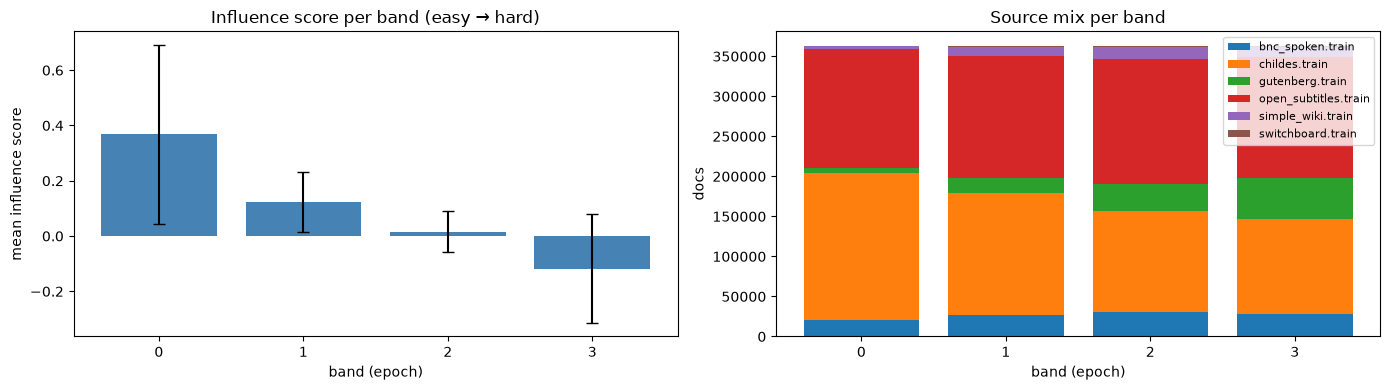

Plot saved to outputs/sequential_bands/band_distribution.png


In [10]:
# ── Cell 7: Visualise influence distribution per band ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: influence score range per band
band_means = [agg[bands[k]].mean() for k in range(N_SEGMENTS)]
band_stds  = [agg[bands[k]].std()  for k in range(N_SEGMENTS)]
axes[0].bar(range(N_SEGMENTS), band_means, yerr=band_stds, color="steelblue", capsize=4)
axes[0].set_xlabel("band (epoch)")
axes[0].set_ylabel("mean influence score")
axes[0].set_title("Influence score per band (easy → hard)")
axes[0].set_xticks(range(N_SEGMENTS))

# Right: source mix stacked bar
bottom = np.zeros(N_SEGMENTS)
colors = plt.cm.tab10.colors
for color, src in zip(colors, sources):
    counts_per_band = [
        sum(1 for i in bands[k] if doc_ids[i].split("#")[0] == src)
        for k in range(N_SEGMENTS)
    ]
    axes[1].bar(range(N_SEGMENTS), counts_per_band, bottom=bottom,
                label=src.replace(".train.txt", ""), color=color)
    bottom += np.array(counts_per_band)
axes[1].set_xlabel("band (epoch)")
axes[1].set_ylabel("docs")
axes[1].set_title("Source mix per band")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].set_xticks(range(N_SEGMENTS))

plt.tight_layout()
plt.savefig(str(OUT / "band_distribution.png"), dpi=150)
plt.show()
print(f"Plot saved to {OUT / 'band_distribution.png'}")

In [11]:
# ── Cell 8: Push epoch files to target Hub dataset repo ──
if TARGET_DATASET_REPO:
    from huggingface_hub import HfApi
    api = HfApi()
    api.create_repo(repo_id=TARGET_DATASET_REPO, repo_type="dataset",
                    exist_ok=True, token=HF_TOKEN)
    print(f"Pushing curriculum files → {TARGET_DATASET_REPO} ...")
    api.upload_folder(
        folder_path=str(curr_dir),
        repo_id=TARGET_DATASET_REPO,
        path_in_repo="curriculum",
        repo_type="dataset",
        token=HF_TOKEN,
        commit_message=f"sequential-bands curriculum  N={N_SEGMENTS} seed={SEED}",
    )
    print("Done.")
else:
    print("TARGET_DATASET_REPO not set — skipping Hub push.")

/Users/adrian.rojas/dev/babylm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pushing curriculum files → flakoash/babylm-curriculum-sliding-window-4bands ...


Processing Files (8 / 8): 100%|██████████|  277MB /  277MB, 3.15MB/s  
New Data Upload: 100%|██████████|  232MB /  232MB, 3.09MB/s  


Done.
